# Winter Arctic sea ice maps from IS2SMGPSIT-V1 (updates through April 2026)

**Summary**: Winter (November–April) mean maps and multi-winter anomaly maps of sea ice thickness, freeboard, and snow depth from a new daily fused ICESat-2–SMOS/SMAP product, now including the 2025–2026 growth season. Map layout follows notebook `11e`, extended to eight winters. The V1 dataset has been submitted to peer review at ESSD, this notebook showcases an additional winter of data using that same processing. 

**Author**: Alek Petty  
**Version history**: Version 1 (09/2026)


In [1]:
### Import notebook dependencies

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib as mpl
import warnings

from utils.read_data_utils import read_is2smgpsitv1_zarr
from utils.plotting_utils import (
    staticArcticMaps_equal_panels,
    compute_gridcell_winter_means,
    static_winter_comparison_lineplot,
)

mpl.rcParams['figure.dpi'] = 200
warnings.filterwarnings('ignore')

In [2]:
# Set some plotting parameters
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "mathtext.fontset": "stixsans",
    "lines.linewidth": 1.0,
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})
mpl.rcParams['font.sans-serif'] = ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans']

## Load IS2SMGPSIT-V1 through April 2026

The published v0.1 store ends on 30 April 2025. The 2025–2026 season is a separate Zarr under `dev_v7_26`. Concatenate the two daily stores, then resample to monthly means so `compute_gridcell_winter_means` can build November–April winters.


In [3]:
%%time
ZARR_V1 = (
    's3://icesat-2-sea-ice-us-west-2/is2smsitgp/dev_v7/zarr/'
    'GPSat_multivar_20181101-20250430.zarr'
)
ZARR_2026 = (
    's3://icesat-2-sea-ice-us-west-2/is2smsitgp/dev_v7_26/zarr/'
    'GPSat_multivar_20250901-20260430.zarr'
)

ds_v1 = read_is2smgpsitv1_zarr(zarr_path=ZARR_V1, load_cache=True, persist=False)
ds_26 = read_is2smgpsitv1_zarr(zarr_path=ZARR_2026, load_cache=True, persist=False)
IS2_SMOS_SMAP = xr.concat([ds_v1, ds_26], dim='time').sortby('time')
print(IS2_SMOS_SMAP)
print('time range:', IS2_SMOS_SMAP.time.values.min(), '→', IS2_SMOS_SMAP.time.values.max())

Loading IS2-SMOS-SMAP (is2smsitgp) Zarr from local cache
cache_path: ./data/cache/GPSat_multivar_20181101-20250430.zarr
Loading IS2-SMOS-SMAP (is2smsitgp) Zarr from local cache
cache_path: ./data/cache/GPSat_multivar_20250901-20260430.zarr
<xarray.Dataset> Size: 6GB
Dimensions:                             (time: 1877, y: 448, x: 304)
Coordinates:
    latitude                            (y, x) float32 545kB 31.1 31.2 ... 34.47
    longitude                           (y, x) float32 545kB 168.3 ... -9.999
  * time                                (time) datetime64[ns] 15kB 2018-11-01...
  * x                                   (x) float32 1kB -3.838e+06 ... 3.738e+06
  * y                                   (y) float32 2kB 5.838e+06 ... -5.338e+06
Data variables: (12/13)
    crs                                 (time) int32 8kB dask.array<chunksize=(93,), meta=np.ndarray>
    freeboard                           (time, y, x) float32 1GB dask.array<chunksize=(93, 448, 304), meta=np.ndarray>
    

In [4]:
# Monthly means (month-start labels) for winter aggregation / map plotting
IS2_monthly = IS2_SMOS_SMAP[['ice_thickness', 'freeboard', 'snow_depth']].resample(time='1MS').mean()
IS2_monthly = IS2_monthly.assign_coords(
    latitude=IS2_SMOS_SMAP.latitude,
    longitude=IS2_SMOS_SMAP.longitude,
)
print(IS2_monthly)
print('monthly times:', IS2_monthly.time.values[0], '→', IS2_monthly.time.values[-1],
      f'({IS2_monthly.sizes["time"]} months)')

<xarray.Dataset> Size: 148MB
Dimensions:        (x: 304, y: 448, time: 90)
Coordinates:
  * x              (x) float32 1kB -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
  * y              (y) float32 2kB 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
  * time           (time) datetime64[ns] 720B 2018-11-01 ... 2026-04-01
    latitude       (y, x) float32 545kB 31.1 31.2 31.3 ... 34.68 34.58 34.47
    longitude      (y, x) float32 545kB 168.3 168.1 168.0 ... -10.18 -9.999
Data variables:
    ice_thickness  (time, y, x) float32 49MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    freeboard      (time, y, x) float32 49MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth     (time, y, x) float32 49MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    caa_uncertainty_caution:    Canadian Arctic Archipelago (CAA; NSIDC-0780 ...
    contact:                    Alek Petty (akpetty@umd.edu)
    description:                ICESat-2–SMOS–SMAP fused dail

## Winter mean maps

Compute November–April grid-cell means for winters starting 2018 through 2025 (eight growth seasons, through April 2026). Absolute fields and anomalies use the same `staticArcticMaps_equal_panels` layout as notebook `11e`.


In [5]:
# Years over which to perform analysis (start year of that winter period)
years = [x for x in range(2018, 2025 + 1)]

freeboard_winter_means = compute_gridcell_winter_means(IS2_monthly.freeboard, years=years)
snow_depth_winter_means = compute_gridcell_winter_means(IS2_monthly.snow_depth, years=years)
thickness_winter_means = compute_gridcell_winter_means(IS2_monthly.ice_thickness, years=years)

# Open-water / missing *ocean* cells are NaN; set those to 0 for mapping.
# Leave land (region_mask outside 1–18) as NaN so Natural Earth land can overlay cleanly.
_rm = IS2_SMOS_SMAP['region_mask']
if 'time' in _rm.dims:
    _rm = _rm.isel(time=0, drop=True)
_ocean = _rm.isin(list(range(1, 19))).compute()

def _fill_open_water(da):
    return da.fillna(0).where(_ocean)

freeboard_winter_means = _fill_open_water(freeboard_winter_means)
snow_depth_winter_means = _fill_open_water(snow_depth_winter_means)
thickness_winter_means = _fill_open_water(thickness_winter_means)

print('winters:', list(thickness_winter_means.time.values))
print('thickness winter means shape:', thickness_winter_means.shape)

winters: ['Nov 2018 - Apr 2019', 'Nov 2019 - Apr 2020', 'Nov 2020 - Apr 2021', 'Nov 2021 - Apr 2022', 'Nov 2022 - Apr 2023', 'Nov 2023 - Apr 2024', 'Nov 2024 - Apr 2025', 'Nov 2025 - Apr 2026']
thickness winter means shape: (8, 448, 304)


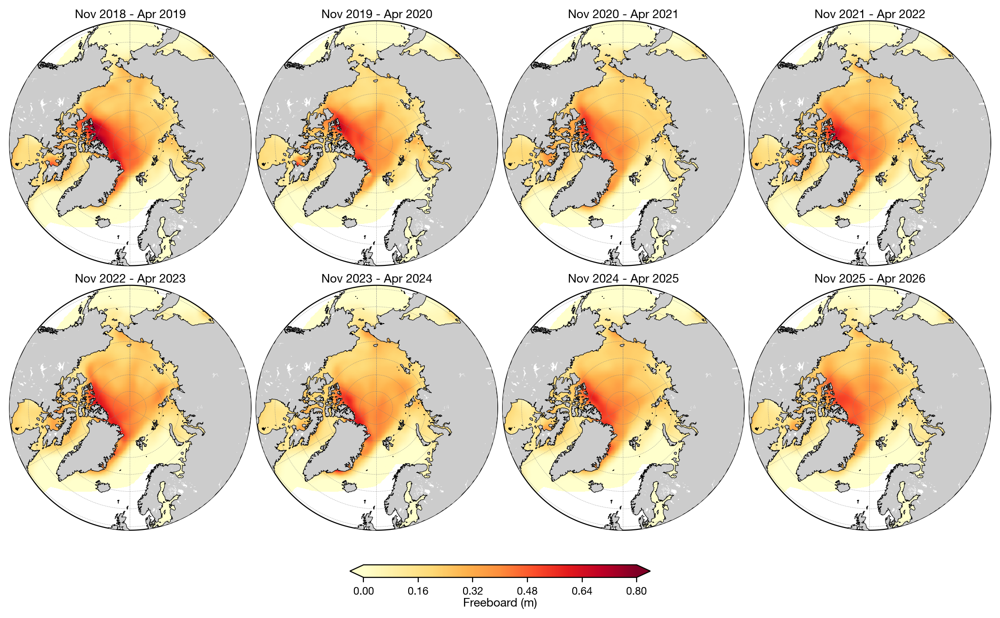

In [6]:
staticArcticMaps_equal_panels(
    freeboard_winter_means,
    dates=freeboard_winter_means.time.values,
    title="",
    set_cbarlabel="Freeboard (m)",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.8,
    out_str='freeboard_winter_2018_2026_is2smgpsitv1',
    ocean_mask=_ocean.values,
)

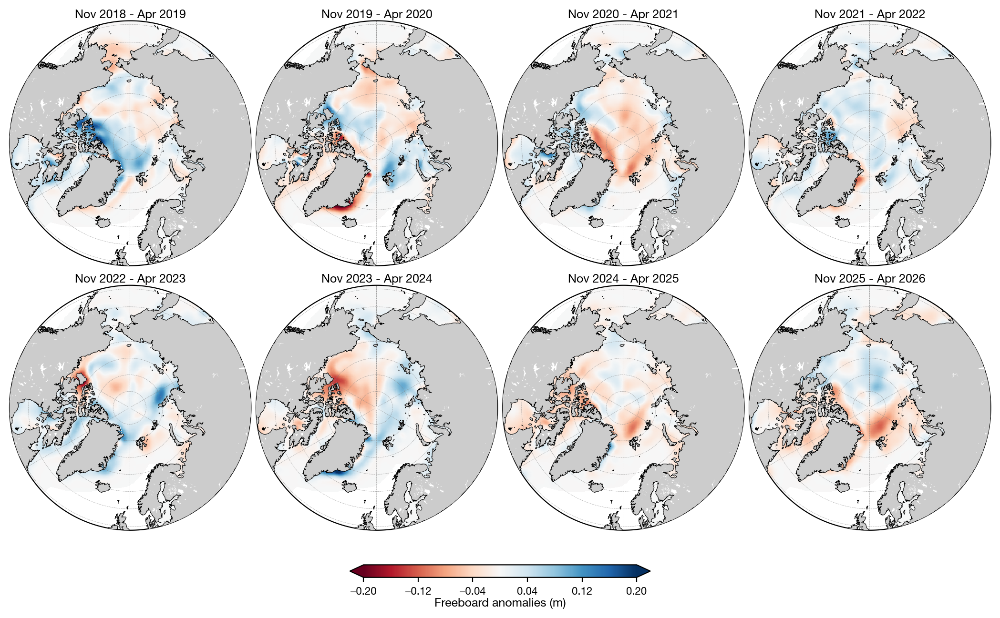

In [7]:
staticArcticMaps_equal_panels(
    freeboard_winter_means - freeboard_winter_means.mean("time"),
    dates=freeboard_winter_means.time.values,
    title="",
    set_cbarlabel="Freeboard anomalies (m)",
    cmap="RdBu",
    vmin=-0.2,
    vmax=0.2,
    out_str='freeboard_winter_2018_2026_anoms_is2smgpsitv1',
    ocean_mask=_ocean.values,
)

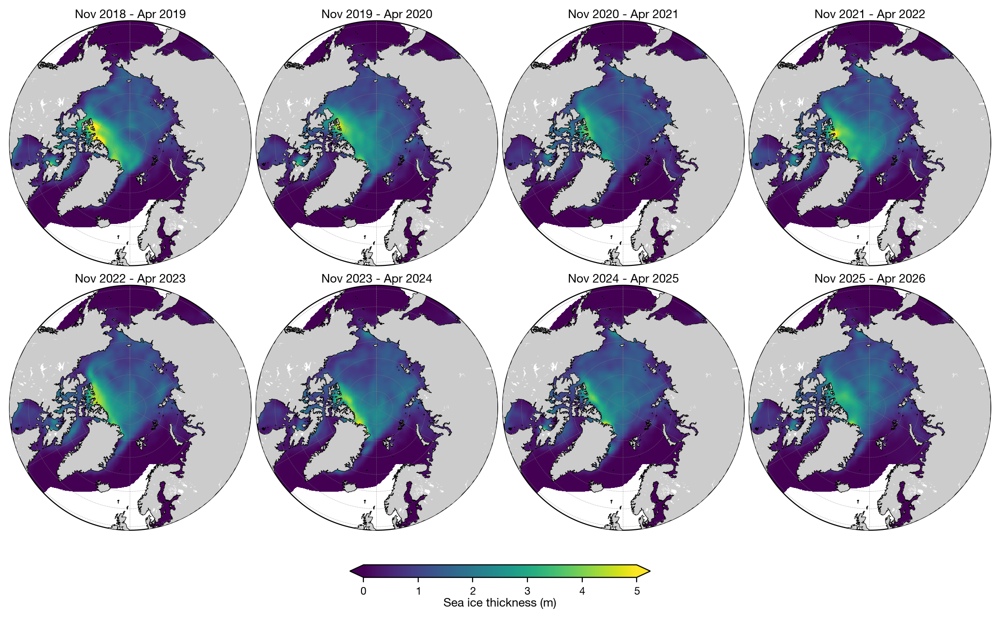

In [8]:
staticArcticMaps_equal_panels(
    thickness_winter_means,
    dates=thickness_winter_means.time.values,
    title="",
    set_cbarlabel="Sea ice thickness (m)",
    cmap="viridis",
    vmin=0,
    vmax=5,
    out_str='thickness_winter_2018_2026_is2smgpsitv1',
    ocean_mask=_ocean.values,
)

April anomaly times: [Timestamp('2019-04-01 00:00:00'), Timestamp('2020-04-01 00:00:00'), Timestamp('2021-04-01 00:00:00'), Timestamp('2022-04-01 00:00:00'), Timestamp('2023-04-01 00:00:00'), Timestamp('2024-04-01 00:00:00'), Timestamp('2025-04-01 00:00:00'), Timestamp('2026-04-01 00:00:00')]


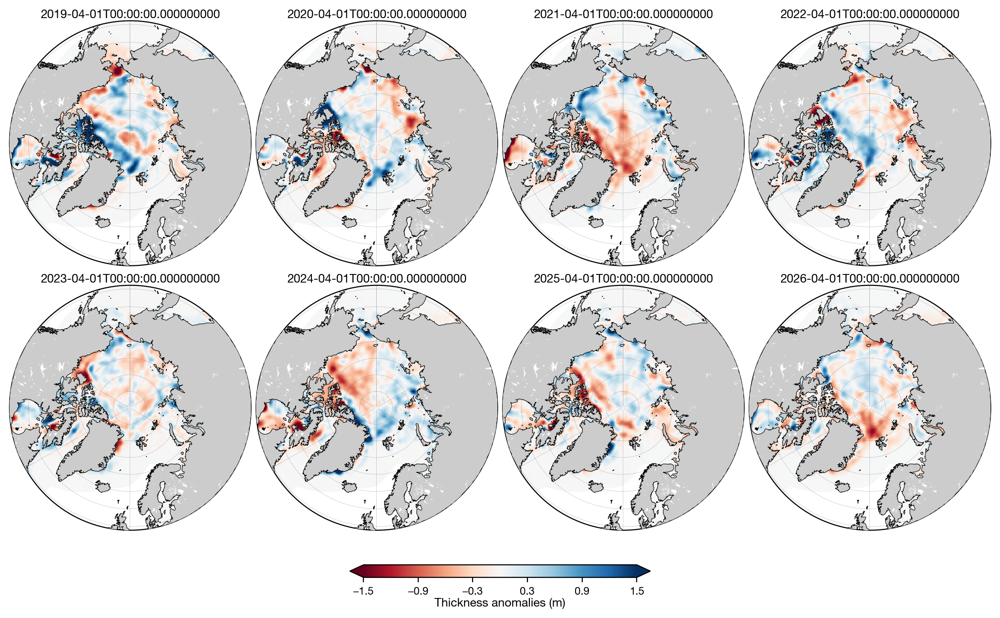

In [9]:
# April-only thickness anomalies
mask = IS2_monthly.time.dt.month == 4
april_thickness = _fill_open_water(IS2_monthly.ice_thickness.sel(time=mask))
april_anom = _fill_open_water(april_thickness - april_thickness.mean('time'))
print('April anomaly times:', list(pd.to_datetime(april_anom.time.values)))
staticArcticMaps_equal_panels(
    april_anom,
    dates=april_anom.time.values,
    title="",
    set_cbarlabel="Thickness anomalies (m)",
    cmap="RdBu",
    vmin=-1.5,
    vmax=1.5,
    out_str='thickness_april_2019_2026_anomalies_is2smgpsitv1',
    ocean_mask=_ocean.values,
)

## April 2026 thickness anomaly

Single-panel map of April 2026 thickness minus the eight-April mean, using the same color scale and land/ocean treatment as the multi-winter April anomaly figure.


April 2026 anomaly time: 2026-04-01T00:00:00.000000000


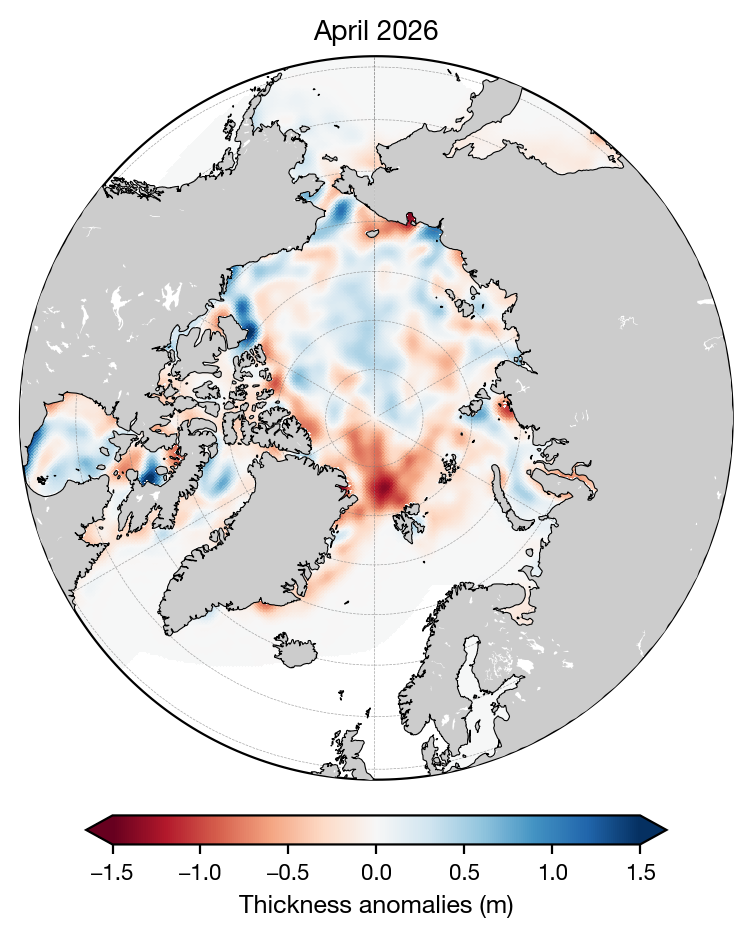

In [ ]:
april_2026 = april_anom.sel(time='2026-04-01', method='nearest')
print('April 2026 anomaly time:', april_2026.time.values)

_nsidc_globe = ccrs.Globe(semimajor_axis=6378273, semiminor_axis=6356889.449)
data_crs = ccrs.Stereographic(
    central_latitude=90, central_longitude=-45, true_scale_latitude=70,
    globe=_nsidc_globe,
)
map_crs = ccrs.NorthPolarStereo(central_longitude=0)

data = np.asarray(april_2026.values, dtype=float)
ocean = np.asarray(_ocean.values).astype(bool)
data = np.where(ocean, data, np.nan)
plot_cmap = mcm.get_cmap('RdBu').copy()
plot_cmap.set_bad('white')

fig = plt.figure(figsize=(5.2, 5.8))
ax = fig.add_subplot(1, 1, 1, projection=map_crs)
ax.set_facecolor('white')
im = ax.pcolormesh(
    april_2026['x'].values, april_2026['y'].values, np.ma.masked_invalid(data),
    transform=data_crs, shading='nearest', cmap=plot_cmap, vmin=-1.5, vmax=1.5, zorder=1,
)
ax.set_extent([-179, 179, 54, 90], crs=ccrs.PlateCarree())
theta = np.linspace(0, 2 * np.pi, 361)
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
ax.set_boundary(mpath.Path(verts * 0.5 + 0.5), transform=ax.transAxes)
ax.set_facecolor('white')
ax.gridlines(draw_labels=False, linewidth=0.25, color='gray', alpha=0.7, linestyle='--', zorder=2)
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='0.80', edgecolor='none', zorder=10)
ax.add_feature(cfeature.LAKES.with_scale('50m'), facecolor='white', edgecolor='none', zorder=11)
ax.coastlines(resolution='50m', linewidth=0.4, color='black', zorder=12)
ax.set_title('April 2026', fontsize=10, fontweight='medium')
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, shrink=0.72, extend='both')
cbar.set_label('Thickness anomalies (m)', fontsize=9)
fig.savefig(
    './figs/maps_thickness_april_2026_anomaly_is2smgpsitv1.png',
    dpi=300, facecolor='white', bbox_inches='tight',
)
plt.show()


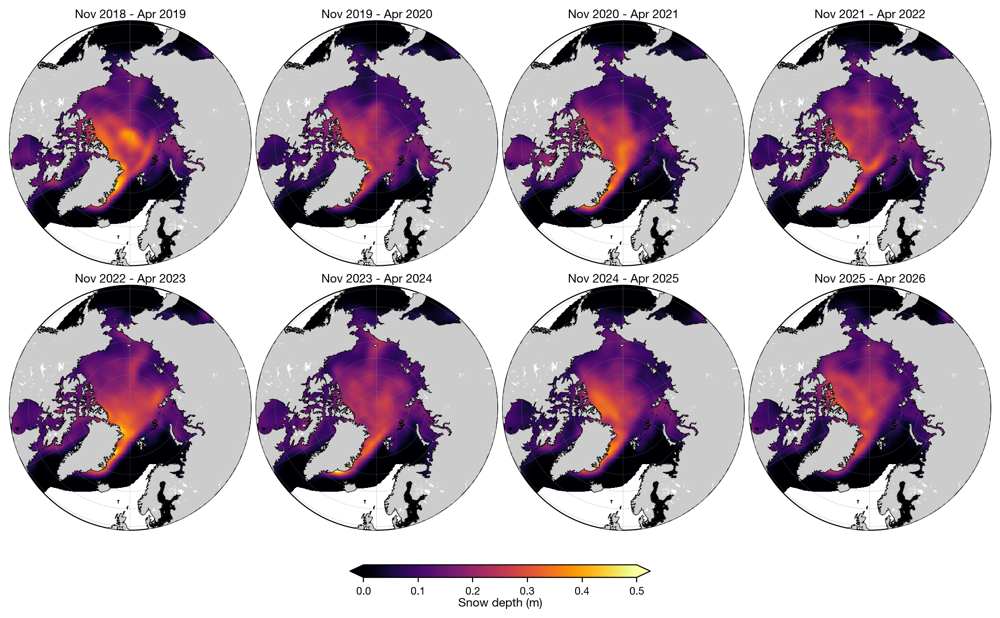

In [11]:
staticArcticMaps_equal_panels(
    snow_depth_winter_means,
    dates=snow_depth_winter_means.time.values,
    title="",
    set_cbarlabel="Snow depth (m)",
    cmap="inferno",
    vmin=0,
    vmax=0.5,
    out_str='snow_depth_winter_2018_2026_is2smgpsitv1',
    ocean_mask=_ocean.values,
)

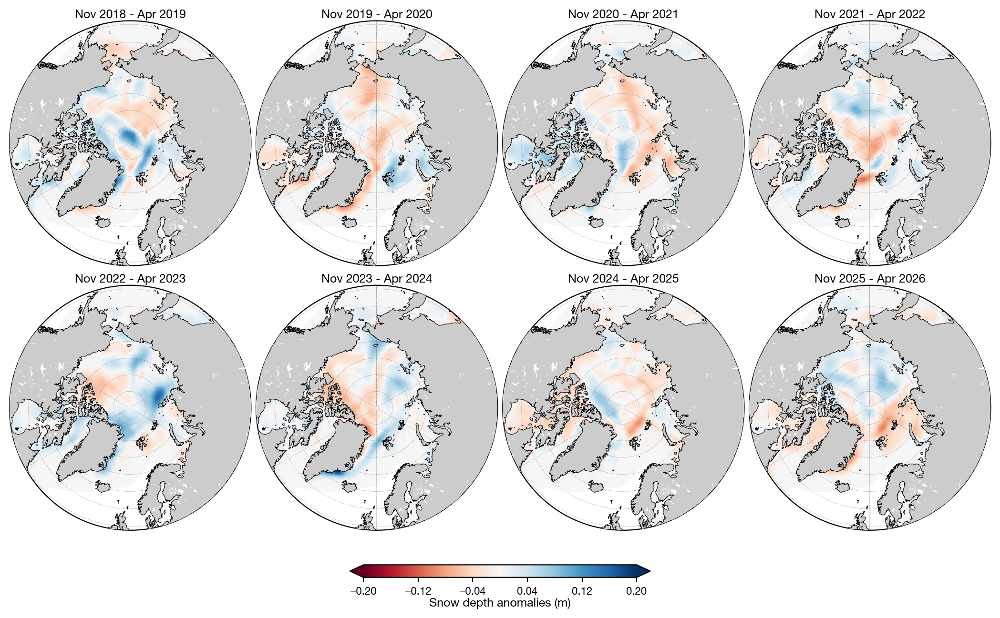

In [12]:
staticArcticMaps_equal_panels(
    snow_depth_winter_means - snow_depth_winter_means.mean("time"),
    dates=snow_depth_winter_means.time.values,
    title="",
    set_cbarlabel="Snow depth anomalies (m)",
    cmap="RdBu",
    vmin=-0.2,
    vmax=0.2,
    out_str='snow_depth_winter_2018_2026_anoms_is2smgpsitv1',
    ocean_mask=_ocean.values,
)

## Inner-Arctic seasonal cycles

Inner Arctic Ocean (NSIDC regions 1–5) monthly means, including the new 2025–2026 winter.


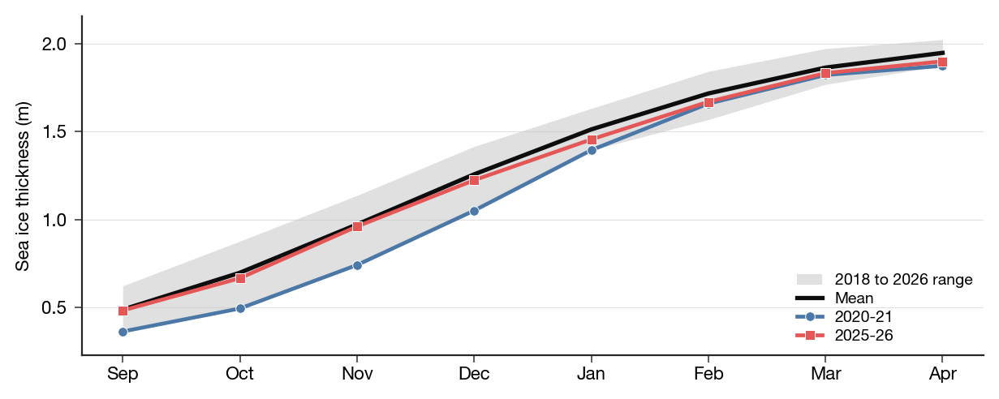

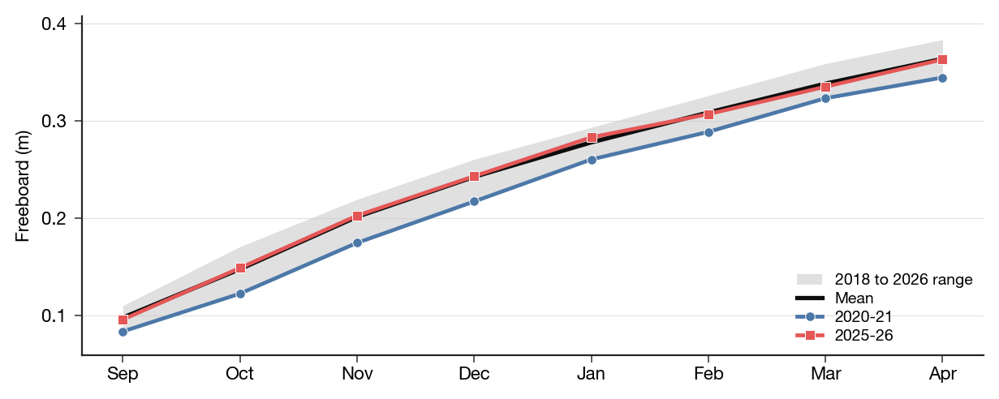

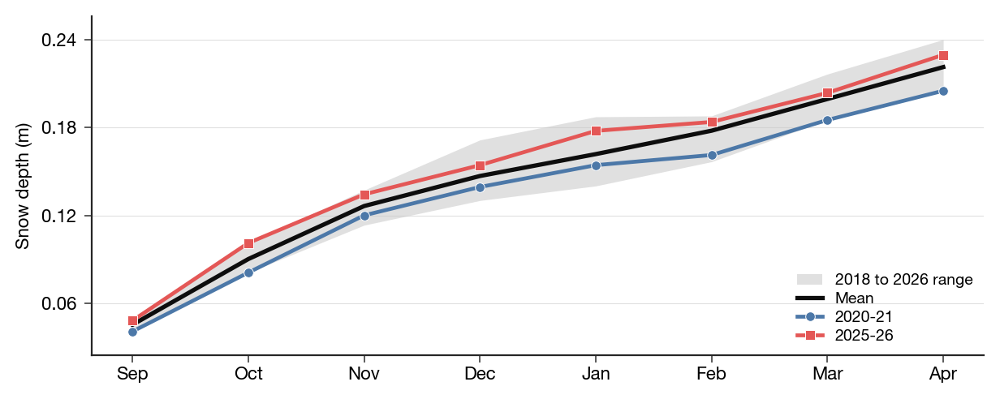

In [13]:
innerArctic = [1, 2, 3, 4, 5]
IS2_innerArctic = IS2_monthly.where(_rm.isin(innerArctic))

# Envelope = all-winter range; black mean; 2020–21 and latest winter as lines.
static_winter_comparison_lineplot(
    IS2_innerArctic.ice_thickness, years=years, start_month="Sep",
    figsize=(6.2, 2.5), set_ylabel='Sea ice thickness',
    set_units='m', loc_pos=4, envelope=True, save_label='is2smgpsitv1_2026',
)
static_winter_comparison_lineplot(
    IS2_innerArctic.freeboard, years=years, start_month="Sep",
    figsize=(6.2, 2.5), set_ylabel='Freeboard',
    set_units='m', loc_pos=4, envelope=True, save_label='is2smgpsitv1_2026',
)
static_winter_comparison_lineplot(
    IS2_innerArctic.snow_depth, years=years, start_month="Sep",
    figsize=(6.2, 2.5), set_ylabel='Snow depth',
    set_units='m', loc_pos=4, envelope=True, save_label='is2smgpsitv1_2026',
)


## Notes

- Winter means use **November–April** (same default as `compute_gridcell_winter_means` / notebooks `2f` and `11e`).
- Daily fields are first averaged to calendar months, then those monthly fields are averaged over each winter.
- The 2025–2026 season is read from `s3://icesat-2-sea-ice-us-west-2/is2smsitgp/dev_v7_26/zarr/GPSat_multivar_20250901-20260430.zarr` and concatenated with the v0.1 store (November 2018–April 2025).
- Figures are written to `./figs/maps_<out_str>.png` with an `_is2smgpsitv1` suffix.
- Anomalies are relative to the eight-winter mean.
- Open-water NaNs in ocean cells (NSIDC region_mask 1–18) are filled with 0 so they take the colormap zero color; land/coast cells stay NaN and are painted grey via `ocean_mask`.
- Seasonal cycles show the min–max winter range as shading, the multi-winter mean (black), and labeled lines for 2020–21 and the most recent winter.
- Stand-alone April 2026 anomaly: `./figs/maps_thickness_april_2026_anomaly_is2smgpsitv1.png`.
